# Otimização Optuna

### Melhores Features

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from src.Data.Processor import DataStreamProcessor

# Definição dos datasets
categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
tamanhos = ['25', '200', '1000']
datasets = [f'data/15k/{cat}/{cat}_{tam}.csv' for cat in categorias for tam in tamanhos]

# Dicionário/Counter para armazenar a contagem global das features
contagem_features = Counter()

for dataset_path in datasets:
    print(f"-> Analisando: {dataset_path}")
    
    try:
        df = pd.read_csv(dataset_path)
    except FileNotFoundError:
        print(f"   [!] Arquivo não encontrado. Pulando...")
        continue
    
    processor = DataStreamProcessor(logging=False)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=0.85,
        top_n_features=25,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Inbound'],
        imputation_method='mediana'
    )
    
    # Adiciona as 25 features deste cenário ao nosso contador global
    contagem_features.update(features)

# Pega as 25 features que mais apareceram somando todos os cenários
top_25_globais = contagem_features.most_common(25)
nomes_features = [f[0] for f in top_25_globais]

print("\nfeatures = [")
for feat in nomes_features:
    print(f"    '{feat}',")
print("]")

### Otimização dos Modelos

In [ ]:
%load_ext autoreload
%autoreload 2

from src.Anomaly.Optimizer import AnomalyOptunaOptimizer
from src.Data.Processor import DataStreamProcessor
import pandas as pd

# Definição dos datasets
categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
tamanhos = ['25', '200', '1000']

# categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
# tamanhos = ['25']

datasets = [f'data/15k/{cat}/{cat}_{tam}.csv' for cat in categorias for tam in tamanhos]

features = [
    'Max Packet Length',
    'Average Packet Size',
    'Fwd Packet Length Min',
    'Min Packet Length',
    'Fwd Packet Length Max',
    'Packet Length Mean',
    'Fwd Packet Length Mean',
    'Avg Fwd Segment Size',
    'min_seg_size_forward',
    'ACK Flag Count',
    'Flow Duration',
    'Fwd IAT Total',
    'Flow IAT Max',
    'Fwd IAT Max',
    'Flow IAT Std',
    'Fwd IAT Std',
    'Fwd IAT Mean',
    'Flow IAT Mean',
    'Total Length of Fwd Packets',
    'Subflow Fwd Bytes',
    'act_data_pkt_fwd',
    'Subflow Fwd Packets',
    'Total Fwd Packets',
    'Down/Up Ratio',
    'Init_Win_bytes_backward',
    'Total Length of Bwd Packets',
    'Subflow Bwd Bytes',
    'Flow IAT Min',
    'Bwd Packet Length Max',
    'URG Flag Count',
    'Bwd IAT Total',
    'Bwd Packets/s',
    'Init_Win_bytes_forward',
]

for dataset_path in datasets:
    print(f"\nIniciando otimização para: {dataset_path}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False, selected_features=features)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="StandardScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Inbound'],
        imputation_method='mediana'
    )
    
    optimizer = AnomalyOptunaOptimizer(
        stream=stream,
        n_trials=150,
        discretization_threshold='params',
        target_names=targets,
        n_runs=5
    )

    melhor_hst = optimizer.optimize('HST')
    # melhor_aif = optimizer.optimize('AIF')
    # melhor_aif = optimizer.optimize('AE', warmup_instances=0)

# Execução do Pipeline


Iniciando treinamento para: Generalização_1000

[AdaptiveIsolationForest] Executando 3 rodada(s) prequencial(is)...

                                                     RELATÓRIO DE MÉTRICAS | BINARY (CLASSE 1)                                                      
Modelo/Algoritmo       | F1 (%)            | Prec (%)          | Rec (%)           | MCC               | FP          | FN          | Tempo (s)      
----------------------------------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------------------------------
AdaptiveIsolationForest | 77.8961 ± 0.1337 | 67.6786 ± 0.2020 | 91.7478 ± 0.0000 |  0.7478 ± 0.0014 | 1126 ± 11   |  212 ± 0    | 5.4399 ± 0.0303

📋 CÓPIA PARA PLANILHA (Selecione as linhas abaixo e cole no Google Sheets/Excel):
Modelo/Algoritmo	F1 (%)	Prec (%)	Rec (%)	MCC	FP	FN	Tempo 

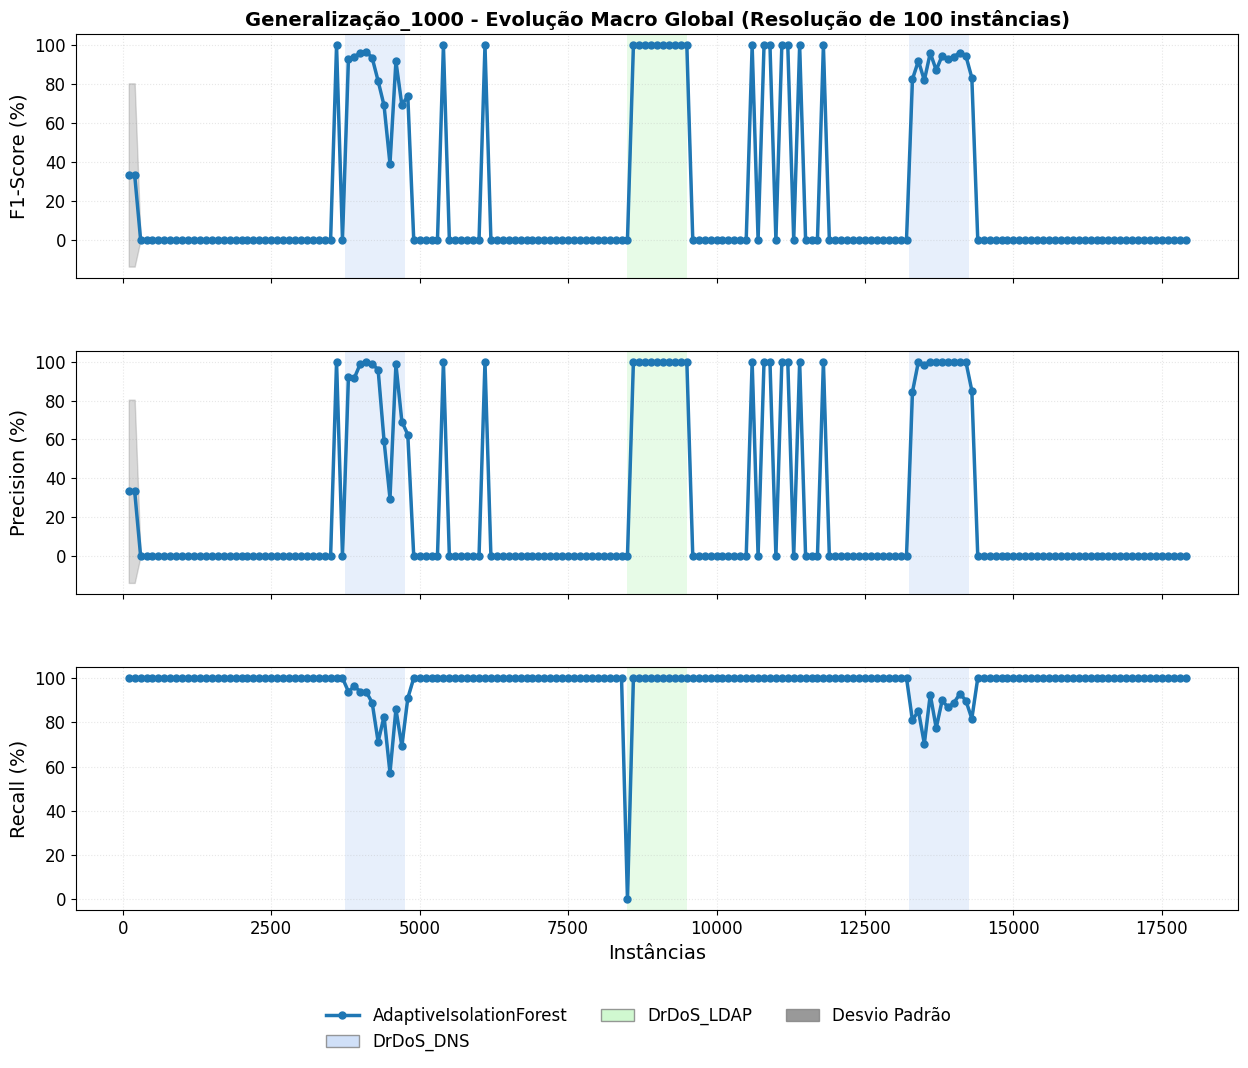

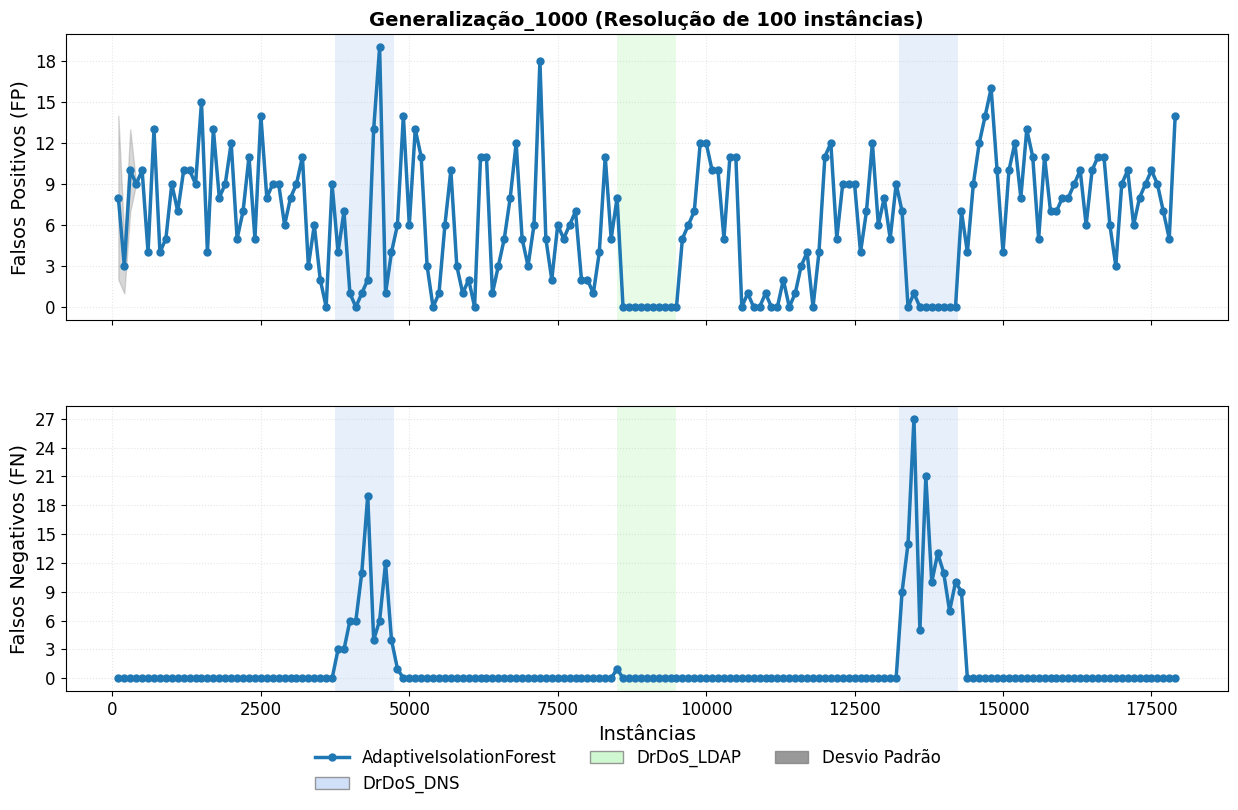

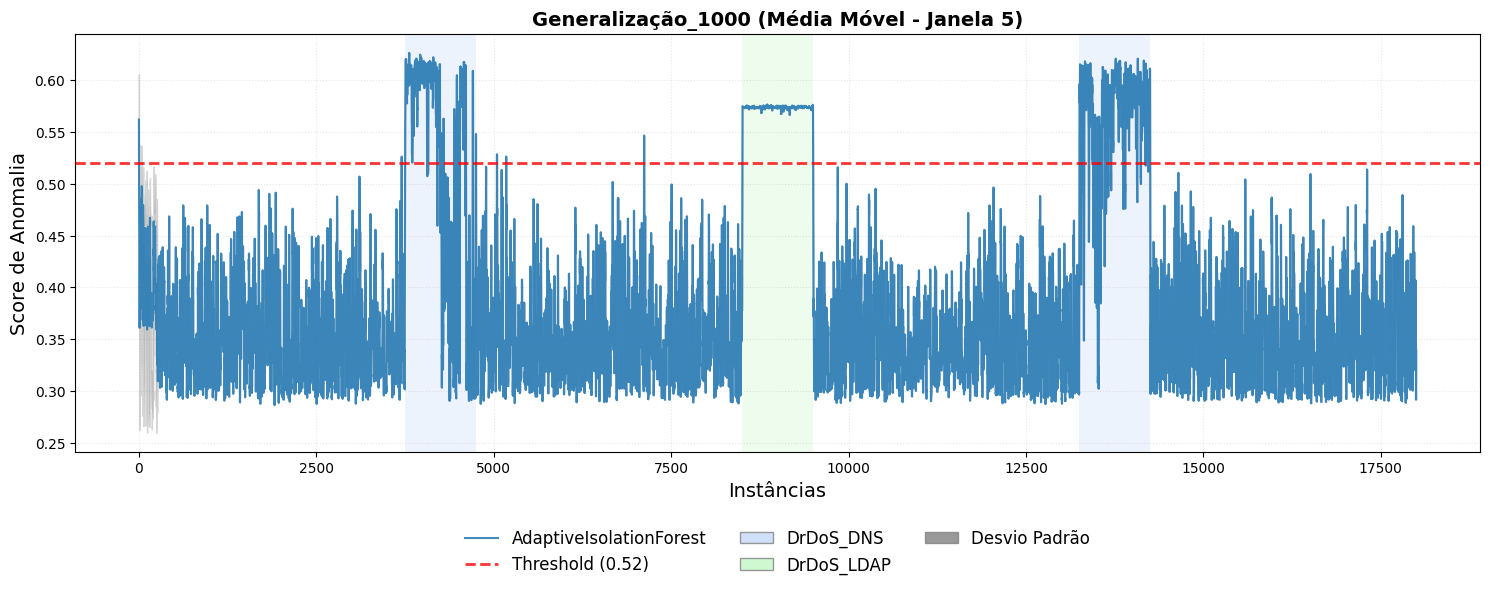

In [1]:
%load_ext autoreload
%autoreload 2

from src.Anomaly.Pipeline import AnomalyExperimentRunner
from src.Anomaly.Models import get_anomaly_models
from src.Data.Processor import DataStreamProcessor
import pandas as pd

# categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
# tamanhos = ['25', '200', '1000']

categorias = ['Generalização']
tamanhos = ['1000']

datasets = [f'data/15k/{cat}/{cat}_{tam}.csv' for cat in categorias for tam in tamanhos]

features = [
    'Max Packet Length',
    'Average Packet Size',
    'Fwd Packet Length Min',
    'Min Packet Length',
    'Fwd Packet Length Max',
    'Packet Length Mean',
    'Fwd Packet Length Mean',
    'Avg Fwd Segment Size',
    'min_seg_size_forward',
    'ACK Flag Count',
    'Flow Duration',
    'Fwd IAT Total',
    'Flow IAT Max',
    'Fwd IAT Max',
    'Flow IAT Std',
    'Fwd IAT Std',
    'Fwd IAT Mean',
    'Flow IAT Mean',
    'Total Length of Fwd Packets',
    'Subflow Fwd Bytes',
    'act_data_pkt_fwd',
    'Subflow Fwd Packets',
    'Total Fwd Packets',
    'Down/Up Ratio',
    'Init_Win_bytes_backward',
    'Total Length of Bwd Packets',
    'Subflow Bwd Bytes',
    'Flow IAT Min',
    'Bwd Packet Length Max',
    'URG Flag Count',
    'Bwd IAT Total',
    'Bwd Packets/s',
    'Init_Win_bytes_forward',
]

for dataset_path in datasets:
    nome_experimento = dataset_path.split('/')[-1].replace('.csv', '')
    print(f"\nIniciando treinamento para: {nome_experimento}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False, selected_features=features)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="StandardScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Inbound'],
        imputation_method='mediana'
    )
    
    algoritmos = get_anomaly_models(
        stream.get_schema(),
        selected_models=['AIF'],
        aif_params={'window_size': 256,
            'n_trees': 2048,
            'height': 10,
            'm_trees': 5,
            'weights': 0.55}
    )
    
    runner = AnomalyExperimentRunner(target_names=targets, n_runs=3)
    
    runner.run_anomaly_evaluation(
        stream,
        algorithms=algoritmos,
        window_size=100,
        warmup_instances=0,
        title=nome_experimento,
        threshold=0.52
    )